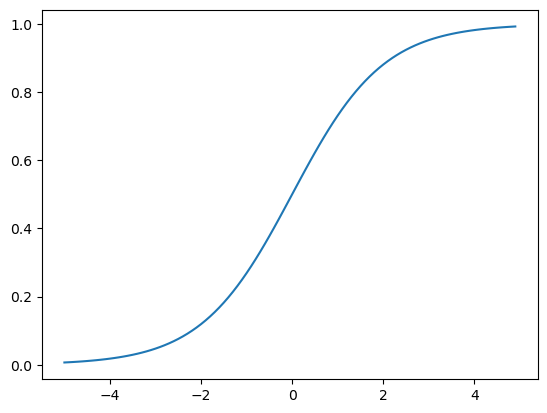

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 (이진 분류)        # 소프트맥스 (다중 분류)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


z = np.arange(-5, 5, 0.1)
phi = sigmoid(z)

plt.plot(z, phi)
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/fish01.csv")
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [6]:
df.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [14]:
# 컬럼명
t1 = {'Species':'종류', 'Weight':'무게', 'Length':'길이', 'Diagonal':'대각선', 'Height':'높이', 'Width':'넓이'}
df.rename(columns=t1, inplace=True)
df


,종류,무게,길이,대각선,높이,넓이
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [16]:
df['종류'].value_counts()

종류
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [19]:
#종류가 Bream, Smelt인 것마 추출해서 df1에 보관
cont = (df['종류'] == 'Bream') | (df['종류'] == 'Smelt')
df1 = df.loc[cont, :]
df1

,종류,무게,길이,대각선,높이,넓이
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
5,Bream,450.0,29.7,34.7,13.6024,4.9274
6,Bream,500.0,29.7,34.5,14.1795,5.2785
7,Bream,390.0,30.0,35.0,12.6700,4.6900
8,Bream,450.0,30.0,35.1,14.0049,4.8438
9,Bream,500.0,30.7,36.2,14.2266,4.9594


In [20]:
# Bream은 종류를 0으로 Smelt는 종류를 1로 변경
cont = (df1['종류'] == 'Bream')
df1.loc[cont, '종류'] = 0

cont = (df1['종류'] == 'Smelt')
df1.loc[cont, '종류'] = 1

df1

,종류,무게,길이,대각선,높이,넓이
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340
5,0,450.0,29.7,34.7,13.6024,4.9274
6,0,500.0,29.7,34.5,14.1795,5.2785
7,0,390.0,30.0,35.0,12.6700,4.6900
8,0,450.0,30.0,35.1,14.0049,4.8438
9,0,500.0,30.7,36.2,14.2266,4.9594


In [23]:
t1 = {"종류": 'int64'}
df1 = df1.astype(t1)
df1.dtypes

종류       int64
무게     float64
길이     float64
대각선    float64
높이     float64
넓이     float64
dtype: object

In [25]:
# 특성 => (n, 5)
# 타겟 => (n, )
x = df1[['무게','길이','대각선','높이','넓이']].values
y = df1['종류'].values

x.shape, y.shape

((49, 5), (49,))

In [26]:
# 훈련, 테스트데이터를 8:2로 분할
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((39, 5), (10, 5), (39,), (10,))

In [27]:
x_train[:5]

array([[685.    ,  34.    ,  39.2   ,  15.9936,   5.3704],
       [ 12.2   ,  13.    ,  13.8   ,   2.277 ,   1.2558],
       [500.    ,  31.    ,  36.2   ,  14.3714,   4.8146],
       [ 10.    ,  11.8   ,  13.1   ,   2.2139,   1.2838],
       [450.    ,  29.7   ,  34.7   ,  13.6024,   4.9274]])

In [30]:
# 평균 0 표준편차 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit은 훈련세트에만
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((39, 5), (10, 5))

In [32]:
x_train_scaled[:5]

array([[ 0.74406626,  0.69763693,  0.68922308,  0.76849347,  0.57569962],
       [-1.31103878, -1.30364028, -1.36106036, -1.43695171, -1.46210795],
       [ 0.17897346,  0.41174018,  0.44706362,  0.50766548,  0.30043265],
       [-1.3177588 , -1.41799898, -1.41756423, -1.44709734, -1.4482406 ],
       [ 0.02624568,  0.28785159,  0.32598389,  0.3840206 ,  0.35629828]])

In [33]:
# 로지스틱회귀 => 분류모델
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(1.0, 1.0)

In [35]:
# 예측하기
import numpy as np
sample = np.array([[250.0, 60.0, 30.0, 15.0, 4.6]])
sample.shape

(1, 5)

In [36]:
# 0이면 Bream이고 1이면 Smelt
model.predict(sample)

array([0])